# Polynomial Regression

In [1]:
# importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
# let's create a non linear data
X = 6 * np.random.rand(100,1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
X.shape, y.shape

((100, 1), (100, 1))

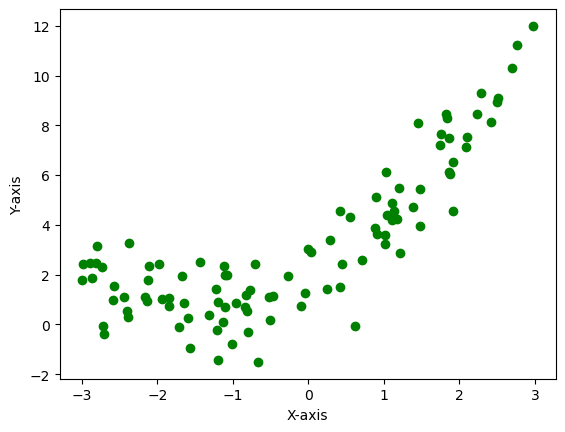

In [4]:
# visualize the data
plt.scatter(X, y, color='g')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [5]:
X[:5]

array([[ 1.20250986],
       [-1.84801176],
       [-2.12534343],
       [ 2.50015512],
       [-2.79508201]])

In [6]:
y[:5]

array([[5.50266254],
       [0.72285263],
       [1.76796894],
       [8.94838555],
       [3.13398496]])

In [8]:
X.min(), X.max()   # the data is in the range of -2 to + 2

(np.float64(-2.992149408528506), np.float64(2.9764038700998707))

In [9]:
# split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 1), (20, 1), (80, 1), (20, 1))

In [11]:
# let's fit the training data into linear model and see how our model performs. 
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [12]:
# checking how linear models performs on the non - linear data
from sklearn.metrics import r2_score
score = r2_score(y_test, regression.predict(X_test))
score

0.7037936573584945

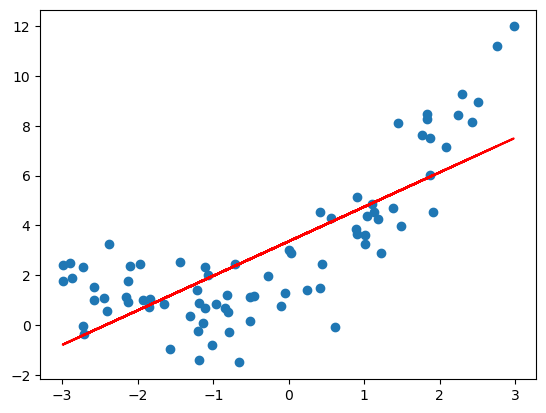

In [13]:
# visualize the model
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color='red')
plt.show()

In [14]:
# let's apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [15]:
X_train_poly[:5]

array([[ 1.        ,  1.87010396,  3.49728881],
       [ 1.        , -2.37814173,  5.65555807],
       [ 1.        , -2.40655837,  5.7915232 ],
       [ 1.        ,  1.12751877,  1.27129859],
       [ 1.        , -2.87064468,  8.24060085]])

In [16]:
X_test_poly[:5]

array([[ 1.        , -2.38655583,  5.69564874],
       [ 1.        ,  0.71361755,  0.50925   ],
       [ 1.        ,  2.09430036,  4.386094  ],
       [ 1.        ,  1.47125974,  2.16460522],
       [ 1.        ,  1.7476392 ,  3.05424277]])

In [17]:
# let's build the model once again
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()
regression_1.fit(X_train_poly, y_train)


LinearRegression()

In [19]:
# calculate the score
from sklearn.metrics import r2_score
y_pred_poly = regression_1.predict(X_test_poly)
score_poly = r2_score(y_test, y_pred_poly)
print(score_poly)

0.9076968091938105


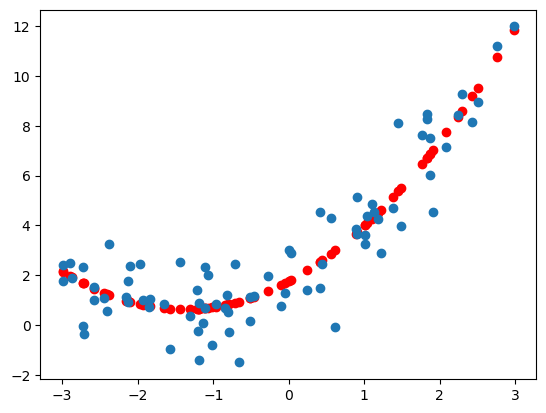

In [21]:
# visualize the train data with predictions
plt.scatter(X_train, regression_1.predict(X_train_poly), color='red')   # best fit line
plt.scatter(X_train, y_train)

In [25]:
# degree 3
from sklearn.preprocessing import PolynomialFeatures
poly_1 = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly_1 = poly_1.fit_transform(X_train)
X_test_poly_1 = poly_1.transform(X_test)

In [26]:
X_train_poly_1[:5]

array([[  1.        ,   1.87010396,   3.49728881,   6.54029364],
       [  1.        ,  -2.37814173,   5.65555807, -13.44971864],
       [  1.        ,  -2.40655837,   5.7915232 , -13.93763864],
       [  1.        ,   1.12751877,   1.27129859,   1.43341302],
       [  1.        ,  -2.87064468,   8.24060085, -23.65583695]])

In [27]:
X_test_poly_1[:5]

array([[  1.        ,  -2.38655583,   5.69564874, -13.5929837 ],
       [  1.        ,   0.71361755,   0.50925   ,   0.36340974],
       [  1.        ,   2.09430036,   4.386094  ,   9.18579824],
       [  1.        ,   1.47125974,   2.16460522,   3.18469651],
       [  1.        ,   1.7476392 ,   3.05424277,   5.33771439]])

In [28]:
# Fit this data to the model
from sklearn.linear_model import LinearRegression
regression_2 = LinearRegression()
regression_2.fit(X_train_poly_1, y_train)

LinearRegression()

In [30]:
y_pred_poly_1 = regression_2.predict(X_test_poly_1)
score_poly_1 = r2_score(y_test, y_pred_poly_1)
print(score_poly_1)

0.9052977880232964


In [39]:
# Predictions of the new Dataset
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly_1.transform(X_new)
X_new_poly[:5]

array([[  1.        ,  -3.        ,   9.        , -27.        ],
       [  1.        ,  -2.96984925,   8.82000455, -26.19408385],
       [  1.        ,  -2.93969849,   8.64182723, -25.40436647],
       [  1.        ,  -2.90954774,   8.46546804, -24.6306834 ],
       [  1.        ,  -2.87939698,   8.290927  , -23.8728702 ]])

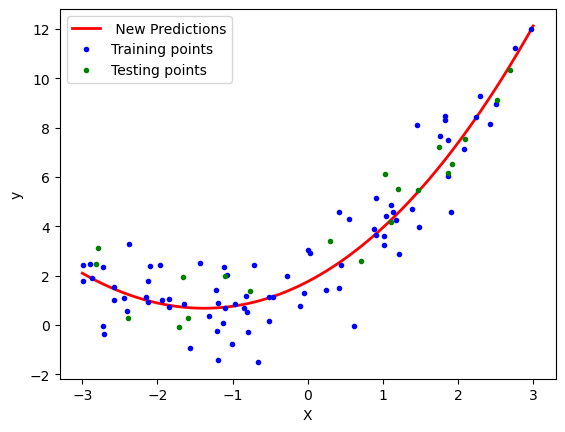

In [42]:
# Model 2 with degree 2 is giving better performance compared to degree 1 and degree 3
y_new = regression_2.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [44]:
# let's make the pipleine
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features =  PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ('poly_features', poly_features),
        ('lin_reg', lin_reg)
    ])

    poly_regression.fit(X_train, y_train)   
    y_pred_new = poly_regression.predict(X_new)
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

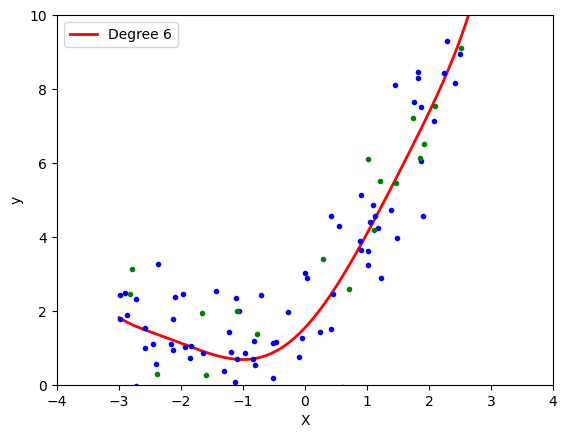

In [45]:
poly_regression(6)

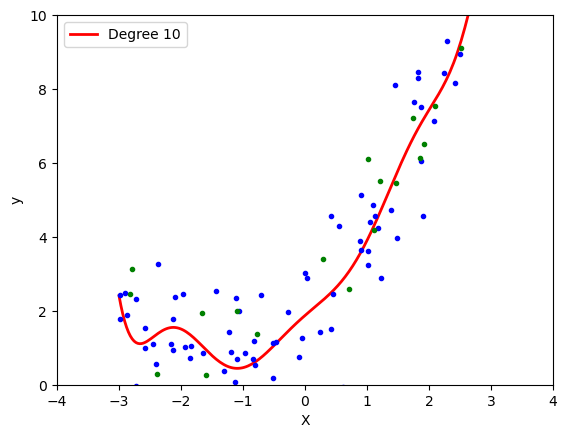

In [46]:
poly_regression(10)